In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# load in all of the data

bags = pd.read_csv('data/ysl_allbags_cleaned.csv')
exchange = pd.read_csv('data/Currency_Exchange_Rates.csv')
duties = pd.read_csv('data/tariff_data.csv')
vat = pd.read_csv('data/vat_rates_by_country.csv')

In [42]:
# get the bags found on all four country sites

pivot_df = bags.pivot_table(index="sku", columns="country", values="price", aggfunc="first")

num_all_4 = (pivot_df.notna().sum(axis=1) == 4).sum()
print(num_all_4) # num of bags (check by SKU) present in all 4 countries, minus duplicates

all4 = pivot_df[pivot_df.notna().all(axis=1)]
all4

valid_skus = all4.index
all4_bags = bags[bags['sku'].isin(valid_skus)]

82


In [43]:
all4_bags

,brand,product_name,price,currency,country,sku
0,Saint Laurent,MOMBASA small in leather,3450.0,$,US,851432AAGWJ1000
1,Saint Laurent,MOMBASA medium in leather,4300.0,$,US,862029AAGWJ1000
2,Saint Laurent,MOMBASA large in leather,5600.0,$,US,A0011MAAGWJ1000
3,Saint Laurent,MOMBASA large in pony hair leather,6100.0,$,US,848811AAFPH1042
4,Saint Laurent,MOMBASA medium in vintage leather,4500.0,$,US,862029AAFDJ2551
...,...,...,...,...,...,...
794,Saint Laurent,SAC DE JOUR NANO号光滑皮革手袋,20500.0,¥,CN,39203502G9W2536
795,Saint Laurent,LE CASSANDRE马毛效果皮革链条手拿包,17500.0,¥,CN,853610AAFQT2499
796,Saint Laurent,LE CASSANDRE粒面羊皮革链条手拿包,14200.0,¥,CN,853610AACYT1000
797,Saint Laurent,KATE粒面皮革手拿包,16300.0,¥,CN,851921AAGBE1000


In [45]:
# convert all prices to USD

exchange['country'] = (
    exchange['country']
    .str.strip() 
)

exchange['country'] = exchange['country'].replace({
    "France":"FR",
    "Italy":"IT",
    "China":"CN"
})

exchange = pd.concat([
    exchange,
    pd.DataFrame({
        'country': ['US'],
        'to_us': [1.0]
    })
], ignore_index=True)

In [46]:
all4_bags = all4_bags.merge(exchange, on="country", how="left")
all4_bags['price_usd'] = all4_bags['price'] * all4_bags['to_us']

In [47]:
# (US_Price + Sales_Tax) - (Converted_Foreign_Price - Vat Refund + Custom_Duty)
# = Savings

sales_tax = 0.0753

In [48]:
# calculate the duty for each bag

all4_bags['duty'] = np.where(all4_bags['country'] == 'US', 0, all4_bags['price_usd'] * 0.1)

In [49]:
# calculate the expected vat refund for each bag

IT_FR_vat_refund = 0.12
CN_vat_refund = 0.11

all4_bags['vat_refund'] = np.where(
    all4_bags['country'].isin(['IT', 'FR']),
    all4_bags['price_usd'] * 0.12,
    np.where(
        all4_bags['country'] == 'CN',
        all4_bags['price_usd'] * 0.11,
        0
    )
)

In [50]:
# use these new features to calculate the final price of each bag in each country

all4_bags['final_price'] = np.where(all4_bags['country'] == 'US', all4_bags['price'] + sales_tax * all4_bags['price'], all4_bags['price_usd'] - all4_bags['vat_refund'] + all4_bags['duty'] )

In [51]:
all4_bags

,brand,product_name,price,currency,country,sku,to_us,price_usd,duty,vat_refund,final_price
0,Saint Laurent,MOMBASA small in leather,3450.0,$,US,851432AAGWJ1000,1.00,3450.0,0.0,0.00,3709.785
1,Saint Laurent,MOMBASA medium in leather,4300.0,$,US,862029AAGWJ1000,1.00,4300.0,0.0,0.00,4623.790
2,Saint Laurent,MOMBASA large in leather,5600.0,$,US,A0011MAAGWJ1000,1.00,5600.0,0.0,0.00,6021.680
3,Saint Laurent,MOMBASA large in pony hair leather,6100.0,$,US,848811AAFPH1042,1.00,6100.0,0.0,0.00,6559.330
4,Saint Laurent,MOMBASA medium in vintage leather,4500.0,$,US,862029AAFDJ2551,1.00,4500.0,0.0,0.00,4838.850
...,...,...,...,...,...,...,...,...,...,...,...
323,Saint Laurent,SAC DE JOUR NANO号光滑皮革手袋,20500.0,¥,CN,39203502G9W2536,0.14,2870.0,287.0,315.70,2841.300
324,Saint Laurent,LE CASSANDRE马毛效果皮革链条手拿包,17500.0,¥,CN,853610AAFQT2499,0.14,2450.0,245.0,269.50,2425.500
325,Saint Laurent,LE CASSANDRE粒面羊皮革链条手拿包,14200.0,¥,CN,853610AACYT1000,0.14,1988.0,198.8,218.68,1968.120
326,Saint Laurent,KATE粒面皮革手拿包,16300.0,¥,CN,851921AAGBE1000,0.14,2282.0,228.2,251.02,2259.180


In [55]:
# translate all to eng (i think china bags weren't translated b4)

us_map = all4_bags[all4_bags["country"] == "US"].set_index("sku")["product_name"]
all4_bags["product_name"] = all4_bags["sku"].map(us_map)

In [56]:
all4_bags

,brand,product_name,price,currency,country,sku,to_us,price_usd,duty,vat_refund,final_price,rank
0,Saint Laurent,MOMBASA small in leather,3450.0,$,US,851432AAGWJ1000,1.00,3450.0,0.0,0.00,3709.785,3.0
1,Saint Laurent,MOMBASA medium in leather,4300.0,$,US,862029AAGWJ1000,1.00,4300.0,0.0,0.00,4623.790,3.0
2,Saint Laurent,MOMBASA large in leather,5600.0,$,US,A0011MAAGWJ1000,1.00,5600.0,0.0,0.00,6021.680,3.0
3,Saint Laurent,MOMBASA large in pony hair leather,6100.0,$,US,848811AAFPH1042,1.00,6100.0,0.0,0.00,6559.330,3.0
4,Saint Laurent,MOMBASA medium in vintage leather,4500.0,$,US,862029AAFDJ2551,1.00,4500.0,0.0,0.00,4838.850,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...
323,Saint Laurent,SAC DE JOUR IN SMOOTH LEATHER - NANO,20500.0,¥,CN,39203502G9W2536,0.14,2870.0,287.0,315.70,2841.300,2.0
324,Saint Laurent,CASSANDRE pouch on chain in pony hair leather,17500.0,¥,CN,853610AAFQT2499,0.14,2450.0,245.0,269.50,2425.500,2.0
325,Saint Laurent,CASSANDRE pouch on chain in lambskin,14200.0,¥,CN,853610AACYT1000,0.14,1988.0,198.8,218.68,1968.120,2.0
326,Saint Laurent,KATE clutch in grain de poudre leather,16300.0,¥,CN,851921AAGBE1000,0.14,2282.0,228.2,251.02,2259.180,2.0


In [57]:
# for each bag, rank from 1-3 its price in each country (use 'dense' to force rankings 1-3 since FR and IT will always be the same)

all4_bags['rank'] = all4_bags.groupby('sku')['final_price'].rank(method='dense', ascending=True)

In [58]:
pivot = all4_bags.pivot(index='product_name', columns='country', values='rank')

In [59]:
pivot

country,CN,FR,IT,US
product_name,,,,
AMALIA hobo in lambskin,2.0,1.0,1.0,3.0
AMALIA hobo in suede,2.0,1.0,1.0,3.0
AMALIA mini hobo in lambskin,3.0,1.0,1.0,2.0
AMALIA mini hobo in suede,3.0,1.0,1.0,2.0
CALYPSO medium in grained lambskin,2.0,1.0,1.0,3.0
...,...,...,...,...
Toy Puffer in shiny leather,2.0,1.0,1.0,3.0
Y TOTE IN LEATHER,2.0,1.0,1.0,3.0
Y tote in suede,2.0,1.0,1.0,3.0


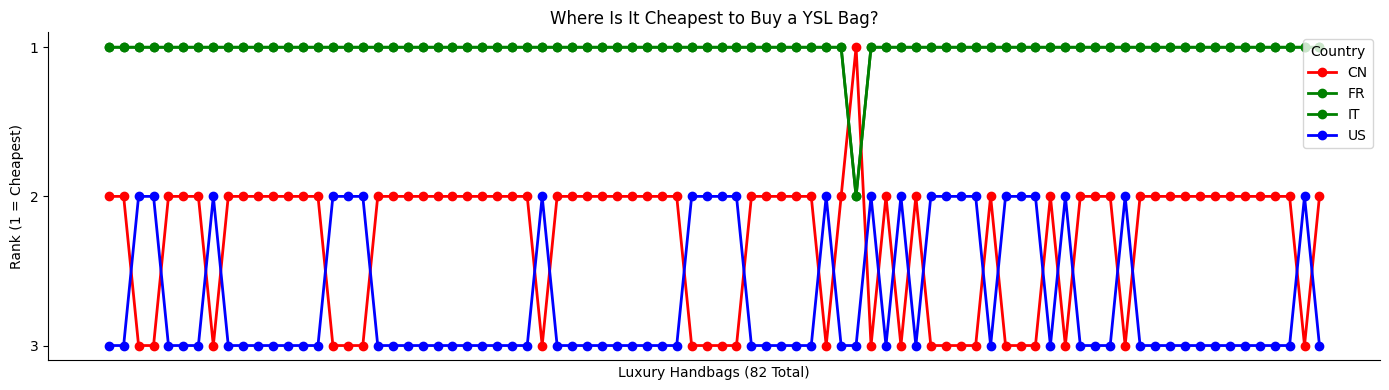

In [ ]:
# create a bump chart ranking the prices for each bag in each country

plt.figure(figsize=(14,4))

countries = pivot.columns
x = np.arange(len(pivot))

colors = {
    'US': 'blue',
    'IT': 'green',
    'FR': 'green',
    'CN': 'red'
}

for country in countries:

    plt.plot(
        x,
        pivot[country],
        marker='o',
        label=country,
        linewidth=2,
        color=colors.get(country, None),
    )

for country in countries:
    if country == "FR":  # skip FR because it's the same as IT, so the lines overlap
        continue

    plt.scatter(
        x,
        pivot[country],
        s=8,             
        color=colors.get(country),
        alpha=0.7
    )


plt.gca().invert_yaxis()
# plt.xticks(x, pivot.index, rotation=45, ha='right')

plt.xticks([])
plt.xlabel('Luxury Handbags (82 Total)')

plt.yticks([1,2,3])
plt.ylabel('Rank (1 = Cheapest)')

plt.title('Where Is It Cheapest to Buy a YSL Bag?')

plt.legend(title='Country', loc = 'upper right')

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [92]:
# find the 10 bags with the biggest diffs in price between countries, and make a plot with price
# not the 10 bags randomly selected earlier - that plot would prob not be very informative
price_pivot = all4_bags.pivot_table(index='product_name',columns='country',values='final_price',aggfunc='first')

price_range = price_pivot.max(axis=1) - price_pivot.min(axis=1)
top10 = price_range.sort_values(ascending=False).head(10).index
price_subset = price_pivot.loc[top10]

price_subset


country,CN,FR,IT,US
product_name,,,,
MOMBASA large in pony hair leather,6375.60,5635.00,5635.00,6559.33
ICARE in quilted lambskin,5654.88,4733.40,4733.40,5484.03
MOMBASA large in leather,5821.20,5184.20,5184.20,6021.68
LARGE Jamie 4.3 in lambskin,4851.00,4169.90,4169.90,4946.38
SAC DE JOUR IN SUPPLE GRAINED LEATHER - SMALL,3742.20,3268.30,3268.30,3978.61
ICARE hobo in quilted suede,4989.60,4282.60,4282.60,4838.85
ICARE Medium in quilted suede,5266.80,4789.75,4789.75,5484.03
AMALIA hobo in suede,4504.50,3831.80,3831.80,4516.26
AMALIA hobo in lambskin,4504.50,3831.80,3831.80,4516.26


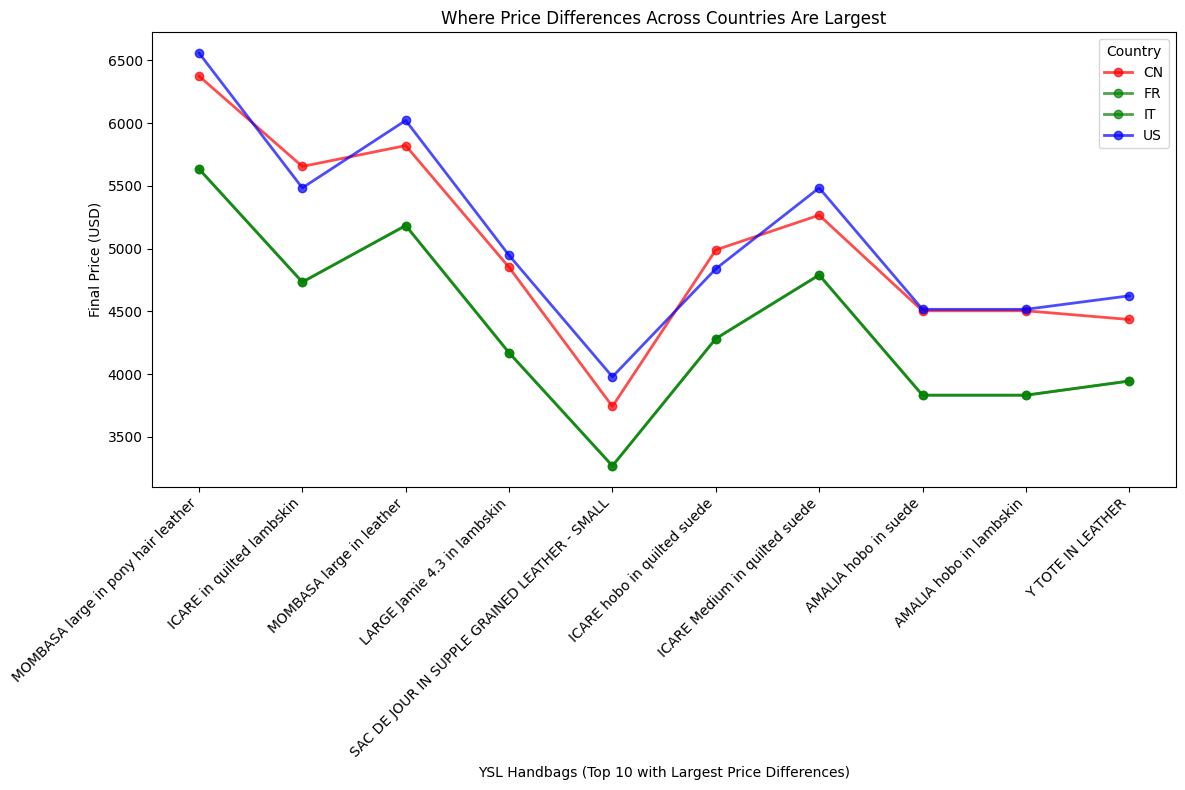

In [95]:
plt.figure(figsize=(12,8))

countries = price_subset.columns

for country in countries:

    plt.plot(
        price_subset.index,
        price_subset[country],
        marker='o',
        linewidth=2,
        color=colors.get(country),
        alpha=0.7,
        label=country
    )

plt.xticks(rotation=45, ha='right')
plt.ylabel('Final Price (USD)')
plt.xlabel('YSL Handbags (Top 10 with Largest Price Differences)')
plt.title('Where Price Differences Across Countries Are Largest')

plt.legend(title='Country')
plt.tight_layout()
plt.show()

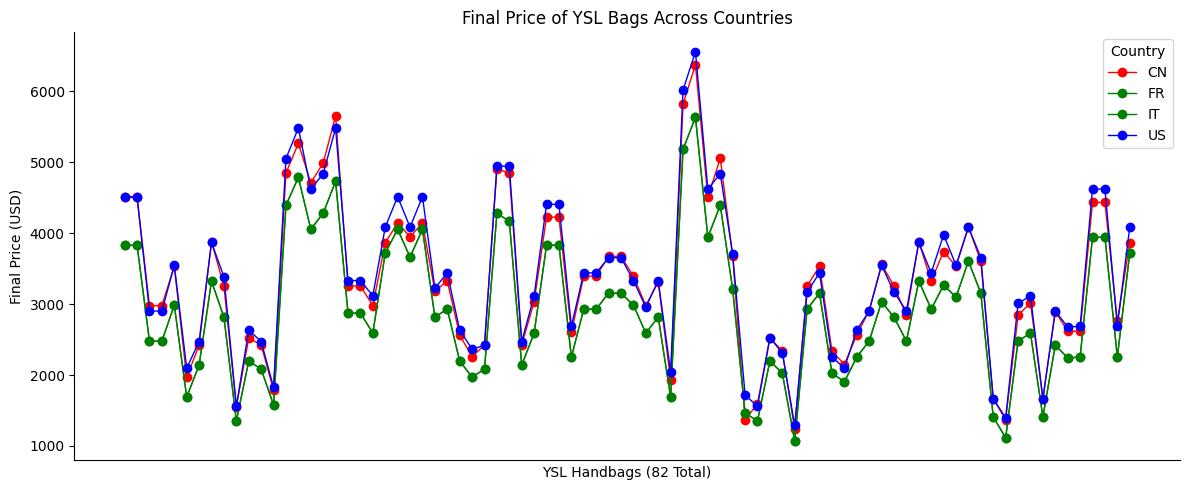

In [107]:
# plot by price again, but back to the full dataset

plt.figure(figsize=(12,5))

countries = price_pivot.columns
x = np.arange(len(price_pivot))

colors = {
    'US': 'blue',
    'IT': 'green',
    'FR': 'green',
    'CN': 'red'
}

for country in countries:

    plt.plot(
        x,
        price_pivot[country],
        marker='o',
        label=country,
        linewidth=1,
        color=colors.get(country, None),
    )

for country in countries:
    if country == "FR":
        s=0
    else:
        s=2


# plt.xticks(x, pivot.index, rotation=45, ha='right')

plt.xticks([])
plt.xlabel('YSL Handbags (82 Total)')

plt.ylabel('Final Price (USD)')

plt.title('Final Price of YSL Bags Across Countries')

plt.legend(title='Country', loc = 'upper right')

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()